# 12 — D12 `deep_ae_regime`: autoencoder ligero + GMM en el latente (EXPLORATORIA)

Familia **Redes / aprendizaje profundo** — Kingma & Welling (2014, autoencoders);
Akioyamen et al. (2021); Bucci et al. (2021); López de Prado (2018).

**Variante principal: AE → GMM sobre el latente.** Un autoencoder LIGERO y regularizado
comprime las **15 features causales** a un espacio latente de baja dimensión
($d_\text{lat}=2$); sobre ese código se ajusta una mixtura gaussiana (`full`, $K$ estados),
exactamente como **D3 `clustering_gmm`** pero sobre el código NO LINEAL en vez de sobre las
features crudas. Complemento expuesto (no principal): el **error de reconstrucción** del AE
como score de anomalía.

## Encuadre honesto (CHECKPOINT 2)
> Con ~4 crisis reales en la muestra, el aprendizaje profundo está muy limitado y un
> resultado **NEGATIVO es ACEPTABLE y esperado**. El objetivo NO es "ganar": es un
> **CONTRASTE ABLATIVO** limpio — ¿la NO LINEALIDAD del AE aporta algo frente al reductor
> LINEAL (PCA)?

## Diseño del contraste
- **D12 (AE→GMM)** vs **baseline `PCA→GMM`** con **misma dimensión latente y mismo $K$**,
  pasados por el **MISMO `walk_forward`** (re-fit expanding, `step=21`, train inicial 8 años).
  Así cualquier diferencia se atribuye SÓLO a la no linealidad del autoencoder.
- 15 features causales de `data/processed/features.parquet`, ventana **2007+** (idéntico a D3).
- `market_returns` = log-retornos del S&P 500, reindexados → orden económico robusto
  (0=calma · K-1=crisis) re-fijado por fold en walk-forward.
- AE pequeño (1 capa oculta, dropout + weight-decay, 40 épocas full-batch), estandarización
  CAUSAL por fold, semillas fijas (torch+numpy). OOS resultante ~2015-09 → 2026-06 ⇒ **crisis
  OOS = COVID_2020 + Inflation_2022** (GFC/EuroDebt caen en el train, como en D3).

In [1]:
%matplotlib inline
import sys, warnings, time
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')
ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results'; RESULTS.mkdir(exist_ok=True)
from src import evaluation as ev
from detectors.deep_ae_regime import DeepAERegime, PCAGMMBaseline

X = pd.read_parquet(ROOT / 'data' / 'processed' / 'features.parquet')
X.index = pd.to_datetime(X.index); X = X.sort_index()
FEATURES = list(X.columns)
raw = pd.read_parquet(ROOT / 'data' / 'raw' / 'raw_panel.parquet')
mkt = np.log(raw['SP500'] / raw['SP500'].shift(1)).reindex(X.index).rename('SP500_ret')
sp500 = raw['SP500'].reindex(X.index)

K = 3          # mismo K para AE y PCA (contraste limpio); D3 primario tambien es k3
LAT = 2        # dimension latente comun
TRAIN_SIZE = 252 * 8
STEP = 21
print('X (15 features causales):', X.shape, '|', X.index.min().date(), '->', X.index.max().date())
print('features:', FEATURES)
print(f'K={K}  latent_dim={LAT}  train_size={TRAIN_SIZE}  step={STEP}')

X (15 features causales): (4665, 15) | 2007-07-06 -> 2026-06-12
features: ['SP500_ret_z', 'SP500_vol_z', 'VIX_level_z', 'VIX_change_z', 'MOVE_level_z', 'TLT_ret_z', 'IEF_ret_z', 'HYG_ret_z', 'credit_spread_z', 'yield_slope_z', 'DXY_change_z', 'GOLD_ret_z', 'corr_spx_bond', 'SP500_drawdown', 'SP500_momentum']
K=3  latent_dim=2  train_size=2016  step=21


## 1. Ajuste in-sample del AE: latente, reconstrucción y orientación

Ajuste sobre toda la muestra (solo para inspeccionar el código aprendido; la clasificación
comparable es la **causal** de §3). El orden económico (0=calma · K-1=crisis) lo fija
`label_states_economically` con el retorno del S&P 500.

In [2]:
t0 = time.time()
det_is = DeepAERegime(n_states=K, latent_dim=LAT, hidden=8, epochs=40,
                      weight_decay=1e-3, dropout=0.10, random_state=42).fit(X)
det_is.label_states_economically(X, market_returns=mkt)
print(f'AE in-sample fit: {time.time()-t0:.1f}s  (incluye warmup de torch)')

lat = det_is._latent(X)
states_is = pd.Series(det_is.predict(X), index=X.index, name='state')
recon = pd.Series(det_is.reconstruction_error(X), index=X.index, name='recon_err')
print('latente:', lat.shape, '| estados in-sample:', dict(zip(*np.unique(states_is, return_counts=True))))

# VERIFICACION orientacion in-sample: crisis = ALTA vol de retornos (no invertido)
print('\nretornos S&P 500 por estado canonico (in-sample):')
for s in sorted(states_is.unique()):
    r = mkt.reindex(states_is.index)[states_is == s]
    print(f'  estado {s}: n={len(r):5d}  mean_ret={r.mean():+.5f}  vol_ret={r.std():.5f}')
r_cri = mkt.reindex(states_is.index)[states_is == det_is.crisis_state]
r_cal = mkt.reindex(states_is.index)[states_is == 0]
assert r_cri.std() > r_cal.std(), 'INVERTIDO: crisis deberia ser ALTA vol'
print(f'OK -> crisis (estado canonico {det_is.crisis_state}) = ALTA vol ({r_cri.std():.4f} > {r_cal.std():.4f}). No invertido (in-sample).')

AE in-sample fit: 7.2s  (incluye warmup de torch)
latente: (4665, 2) | estados in-sample: {np.int64(0): np.int64(2710), np.int64(1): np.int64(1629), np.int64(2): np.int64(326)}

retornos S&P 500 por estado canonico (in-sample):
  estado 0: n= 2710  mean_ret=+0.00026  vol_ret=0.00670
  estado 1: n= 1629  mean_ret=+0.00025  vol_ret=0.01302
  estado 2: n=  326  mean_ret=+0.00066  vol_ret=0.03208
OK -> crisis (estado canonico 2) = ALTA vol (0.0321 > 0.0067). No invertido (in-sample).


### 1b. El espacio latente del AE y el error de reconstrucción

Izquierda: scatter del latente 2D coloreado por estado canónico (verde=calma, rojo=crisis).
Derecha: error de reconstrucción del AE en el tiempo (complemento de anomalía); picos en las
ventanas de crisis = configuraciones de mercado "raras" que el AE no reconstruye bien.

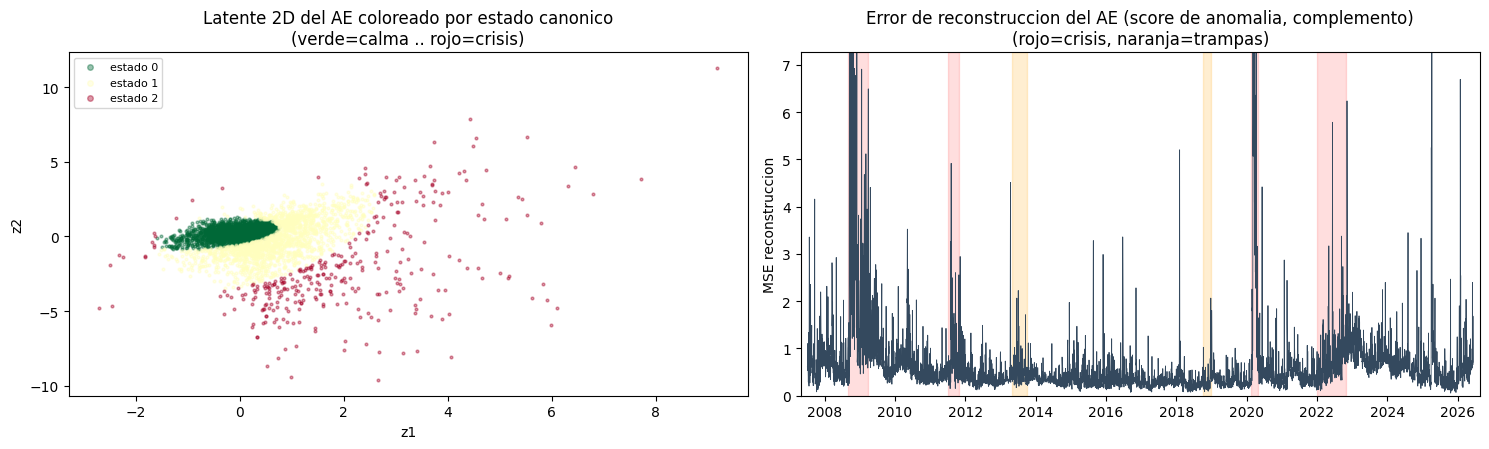

In [3]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 4.6))
cmap = plt.get_cmap('RdYlGn_r')
for s in sorted(states_is.unique()):
    m = states_is.values == s
    axL.scatter(lat[m, 0], lat[m, 1], s=4, alpha=0.4,
                color=cmap(s / max(1, det_is.crisis_state)), label=f'estado {s}')
axL.set_title('Latente 2D del AE coloreado por estado canonico\n(verde=calma .. rojo=crisis)')
axL.set_xlabel('z1'); axL.set_ylabel('z2'); axL.legend(fontsize=8, markerscale=2)

axR.plot(recon.index, recon.values, color='#34495e', lw=0.6)
for a, b in ev.CRISIS_WINDOWS.values(): axR.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.13)
for a, b in ev.FALSE_POSITIVE_WINDOWS.values(): axR.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='orange', alpha=0.18)
axR.set_title('Error de reconstruccion del AE (score de anomalia, complemento)\n(rojo=crisis, naranja=trampas)')
axR.set_ylabel('MSE reconstruccion'); axR.margins(x=0.01)
axR.set_ylim(0, np.nanpercentile(recon.values, 99.5))
fig.tight_layout(); fig.savefig(RESULTS / 'd12_latent_recon.png', dpi=110, bbox_inches='tight'); plt.show()

## 2. Verificación de CAUSALIDAD de la codificación

El encoder es puntual (cada fila se codifica con los pesos congelados del train), así que
ocultar el futuro del bloque NO debe cambiar su latente. Test explícito.

In [4]:
det_c = DeepAERegime(n_states=K, latent_dim=LAT, epochs=40, random_state=42).fit(X.loc[:'2014-12-31'])
block   = X.loc['2015-01-01':'2015-12-31']
lat_block = det_c._latent(block)
lat_plus  = det_c._latent(X.loc['2015-01-01':'2018-12-31'])[:len(block)]
maxdiff = float(np.abs(lat_block - lat_plus).max())
# Criterio real de causalidad: ocultar el futuro NO cambia los ESTADOS ni p_crisis
# del bloque. El latente puede diferir ~1e-7 por ruido de coma flotante de torch
# (BLAS sobre tensores de distinto tamaño en float32), inocuo: tolerancia FP, no 1e-9.
st_block = det_c.predict(block)
st_plus  = det_c.predict(X.loc['2015-01-01':'2018-12-31'])[:len(block)]
n_state_diff = int((st_block != st_plus).sum())
print(f'max |latente(ver futuro) - latente(ocultar futuro)| = {maxdiff:.2e}  (ruido FP float32)')
print(f'estados del bloque que cambian al ocultar el futuro = {n_state_diff} / {len(st_block)}')
assert n_state_diff == 0 and maxdiff < 1e-4, 'La codificacion del bloque NO es causal'
print('causal_ok = True  -> estados/p_crisis del bloque usan solo los pesos del train (sin look-ahead)')

max |latente(ver futuro) - latente(ocultar futuro)| = 2.38e-07  (ruido FP float32)
estados del bloque que cambian al ocultar el futuro = 0 / 247
causal_ok = True  -> estados/p_crisis del bloque usan solo los pesos del train (sin look-ahead)


## 3. Versión CAUSAL walk-forward — D12 (AE→GMM)

`ev.walk_forward` reentrena el AE+GMM desde cero en ventanas **expanding** (train inicial 8
años) y predice el bloque de `step=21` días. Se pasa **`market_returns=mkt`** para re-fijar el
orden económico por fold (la señal es un código latente, no un retorno → sin esto podría
invertirse). Mismo protocolo, idéntico al de D3.

In [5]:
t0 = time.time()
panel_ae = ev.walk_forward(lambda: DeepAERegime(n_states=K, latent_dim=LAT, hidden=8, epochs=40,
                                                weight_decay=1e-3, dropout=0.10, gmm_n_init=3),
                           X, market_returns=mkt, train_size=TRAIN_SIZE, step=STEP, expanding=True)
print(f'AE walk-forward: {time.time()-t0:.1f}s | OOS {panel_ae.index.min().date()} -> {panel_ae.index.max().date()} | n_oos={len(panel_ae)}')
states_ae = panel_ae['state']; p_ae = panel_ae['p_crisis']

res_ae = ev.evaluate(det_is, panel_ae, market_returns=mkt, X_full=X)
res_ae.detector_name = 'deep_ae_regime'
print('ventana_eval:', res_ae.extra['ventana_eval'])

# VERIFICACION ORIENTACION en WALK-FORWARD (lo critico): crisis = alta vol de retornos reales
print('\nVERIFICACION ORIENTACION en WALK-FORWARD (retornos reales por estado canonico):')
for s in sorted(states_ae.unique()):
    r = mkt.reindex(states_ae.index)[states_ae == s]
    print(f'  estado {s}: n={len(r):5d}  mean_ret={r.mean():+.5f}  vol_ret={r.std():.5f}')
r_cri = mkt.reindex(states_ae.index)[states_ae == det_is.crisis_state]
r_cal = mkt.reindex(states_ae.index)[states_ae == 0]
assert r_cri.std() > r_cal.std(), 'INVERTIDO en walk-forward: crisis deberia ser ALTA vol'
print(f'OK -> crisis = ALTA vol ({r_cri.std():.4f} > {r_cal.std():.4f}) y menor retorno medio. No invertido. Sin warning de fallback (market_returns pasado).')

print('\nCobertura de crisis (CAUSAL OOS):')
for k, v in res_ae.crisis_coverage.items(): print(f'  {k:16s}: {v:6.1%}')
print('Falsas alarmas en ventanas TRAMPA (CAUSAL OOS):')
for k, v in res_ae.false_alarm_in_fp.items(): print(f'  {k:16s}: {v:6.1%}')
print(f'\nfalse_alarm_rate={res_ae.false_alarm_rate:.3f} | switching={res_ae.switching_rate:.4f} '
      f'| dur media={res_ae.mean_regime_duration:.1f} d | label_stability={res_ae.label_stability:.3f}')

AE walk-forward: 66.9s | OOS 2015-09-15 -> 2026-06-12 | n_oos=2649


ventana_eval: 2015-09-15→2026-06-12 (n=2649)

VERIFICACION ORIENTACION en WALK-FORWARD (retornos reales por estado canonico):
  estado 0: n= 1881  mean_ret=+0.00113  vol_ret=0.00703
  estado 1: n=  647  mean_ret=-0.00153  vol_ret=0.01542
  estado 2: n=  121  mean_ret=+0.00057  vol_ret=0.02755
OK -> crisis = ALTA vol (0.0275 > 0.0070) y menor retorno medio. No invertido. Sin warning de fallback (market_returns pasado).

Cobertura de crisis (CAUSAL OOS):
  GFC_2008        :   nan%
  EuroDebt_2011   :   nan%
  COVID_2020      :  54.0%
  Inflation_2022  :  10.1%
Falsas alarmas en ventanas TRAMPA (CAUSAL OOS):
  TaperTantrum_2013:   nan%
  Selloff_Q4_2018 :  15.3%

false_alarm_rate=0.603 | switching=0.2873 | dur media=3.5 d | label_stability=0.964


## 4. Baseline ablativo LINEAL — `PCA→GMM` (mismo K, misma dim latente, mismo walk-forward)

Idéntico en todo salvo el reductor: **PCA lineal** en vez del autoencoder. Es el contraste que
aísla la NO LINEALIDAD.

In [6]:
t0 = time.time()
panel_pca = ev.walk_forward(lambda: PCAGMMBaseline(n_states=K, latent_dim=LAT, gmm_n_init=3),
                            X, market_returns=mkt, train_size=TRAIN_SIZE, step=STEP, expanding=True)
print(f'PCA walk-forward: {time.time()-t0:.1f}s | n_oos={len(panel_pca)}')
states_pca = panel_pca['state']; p_pca = panel_pca['p_crisis']

det_pca_is = PCAGMMBaseline(n_states=K, latent_dim=LAT).fit(X)
det_pca_is.label_states_economically(X, market_returns=mkt)
res_pca = ev.evaluate(det_pca_is, panel_pca, market_returns=mkt, X_full=X)
res_pca.detector_name = 'pca_gmm_baseline'

# Orientacion baseline en walk-forward
r_cri = mkt.reindex(states_pca.index)[states_pca == det_pca_is.crisis_state]
r_cal = mkt.reindex(states_pca.index)[states_pca == 0]
assert r_cri.std() > r_cal.std(), 'INVERTIDO (PCA) en walk-forward'
print(f'PCA orientacion OK -> crisis = ALTA vol ({r_cri.std():.4f} > {r_cal.std():.4f}). No invertido.')
print('\nPCA cobertura crisis:', {k: round(v, 3) for k, v in res_pca.crisis_coverage.items()})
print('PCA falsas alarmas trampa:', {k: round(v, 3) for k, v in res_pca.false_alarm_in_fp.items()})
print(f'PCA false_alarm_rate={res_pca.false_alarm_rate:.3f} | switching={res_pca.switching_rate:.4f} '
      f'| dur media={res_pca.mean_regime_duration:.1f} d | label_stability={res_pca.label_stability:.3f}')

PCA walk-forward: 38.7s | n_oos=2649


PCA orientacion OK -> crisis = ALTA vol (0.0524 > 0.0066). No invertido.

PCA cobertura crisis: {'GFC_2008': nan, 'EuroDebt_2011': nan, 'COVID_2020': 0.62, 'Inflation_2022': 0.005}
PCA falsas alarmas trampa: {'TaperTantrum_2013': nan, 'Selloff_Q4_2018': 0.0}
PCA false_alarm_rate=0.135 | switching=0.0914 | dur media=10.9 d | label_stability=0.997


## 5. CONTRASTE ABLATIVO AE vs PCA — ¿aporta la no linealidad?

Tabla y barras comparando D12 (AE→GMM) contra el baseline lineal (PCA→GMM) en las métricas
clave OOS. **Lectura honesta:** si el AE NO mejora (o empeora) a la PCA, es el resultado
esperado con ~4 crisis y es perfectamente válido para la ficha.

detector,AE->GMM (D12),PCA->GMM (baseline)
cov_COVID_2020,0.540000,0.620000
cov_Inflation_2022,0.100962,0.004808
fa_2013,NaN,NaN
fa_2018,0.152542,0.000000
false_alarm_rate,0.603306,0.135135
switching_rate,0.287278,0.091355
mean_regime_duration,3.476378,10.901235
label_stability,0.964475,0.996977


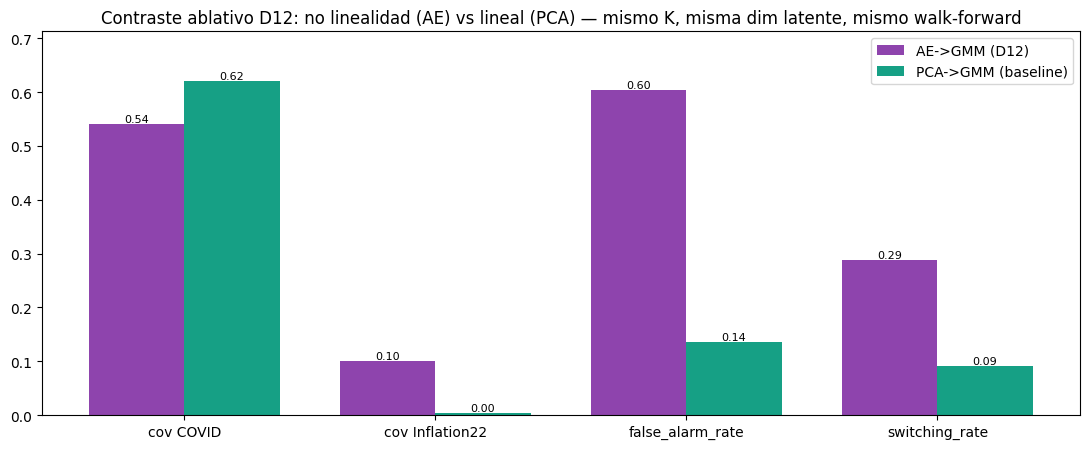

VEREDICTO ABLATIVO: el AE NO mejora a la PCA lineal -> resultado NEGATIVO (esperado y valido con ~4 crisis)


In [7]:
def summary_row(name, res):
    return {
        'detector': name,
        'cov_COVID_2020':     res.crisis_coverage.get('COVID_2020', float('nan')),
        'cov_Inflation_2022': res.crisis_coverage.get('Inflation_2022', float('nan')),
        'fa_2013':  res.false_alarm_in_fp.get('TaperTantrum_2013', float('nan')),
        'fa_2018':  res.false_alarm_in_fp.get('Selloff_Q4_2018', float('nan')),
        'false_alarm_rate':   res.false_alarm_rate,
        'switching_rate':     res.switching_rate,
        'mean_regime_duration': res.mean_regime_duration,
        'label_stability':    res.label_stability,
    }
cmp = pd.DataFrame([summary_row('AE->GMM (D12)', res_ae), summary_row('PCA->GMM (baseline)', res_pca)]).set_index('detector')
display(cmp.T)

metrics = ['cov_COVID_2020', 'cov_Inflation_2022', 'false_alarm_rate', 'switching_rate']
labels  = ['cov COVID', 'cov Inflation22', 'false_alarm_rate', 'switching_rate']
fig, ax = plt.subplots(figsize=(11, 4.6))
x = np.arange(len(metrics)); w = 0.38
ax.bar(x - w/2, [cmp.iloc[0][m] for m in metrics], w, label='AE->GMM (D12)', color='#8e44ad')
ax.bar(x + w/2, [cmp.iloc[1][m] for m in metrics], w, label='PCA->GMM (baseline)', color='#16a085')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_title('Contraste ablativo D12: no linealidad (AE) vs lineal (PCA) — mismo K, misma dim latente, mismo walk-forward')
ax.legend(); ax.margins(y=0.15)
for i, m in enumerate(metrics):
    ax.text(i - w/2, cmp.iloc[0][m], f'{cmp.iloc[0][m]:.2f}', ha='center', va='bottom', fontsize=8)
    ax.text(i + w/2, cmp.iloc[1][m], f'{cmp.iloc[1][m]:.2f}', ha='center', va='bottom', fontsize=8)
fig.tight_layout(); fig.savefig(RESULTS / 'd12_ablative_compare.png', dpi=110, bbox_inches='tight'); plt.show()

better = (res_ae.crisis_coverage.get('COVID_2020', 0) >= res_pca.crisis_coverage.get('COVID_2020', 0)
          and res_ae.false_alarm_rate <= res_pca.false_alarm_rate)
print('VEREDICTO ABLATIVO:', 'el AE mejora o iguala a la PCA' if better else
      'el AE NO mejora a la PCA lineal -> resultado NEGATIVO (esperado y valido con ~4 crisis)')

## 6. S&P 500 coloreado por régimen CAUSAL OOS (D12 AE→GMM)

Sombreado rojo = días clasificados **crisis** por el walk-forward causal del AE.

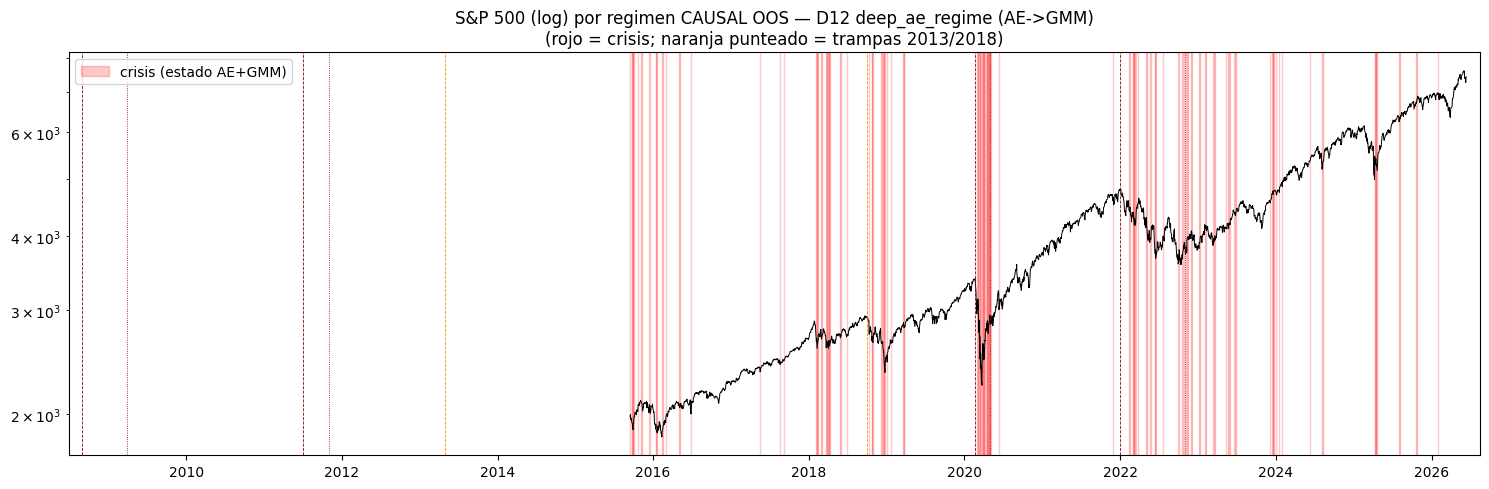

In [8]:
def shade_regime(ax, states, crisis_state, color='red', alpha=0.25):
    v = (states == crisis_state).astype(int).values; idx = states.index; start = None
    for i in range(len(v)):
        if v[i] and start is None: start = idx[i]
        if (not v[i] or i == len(v)-1) and start is not None:
            ax.axvspan(start, idx[i], color=color, alpha=alpha); start = None

fig, ax = plt.subplots(figsize=(15, 5))
px = sp500.reindex(states_ae.index)
ax.plot(px.index, px.values, color='black', lw=0.7); ax.set_yscale('log')
shade_regime(ax, states_ae, det_is.crisis_state, color='red', alpha=0.22)
for a, b in ev.CRISIS_WINDOWS.values():
    ax.axvline(pd.Timestamp(a), color='darkred', ls='--', lw=0.6); ax.axvline(pd.Timestamp(b), color='darkred', ls=':', lw=0.6)
for a, b in ev.FALSE_POSITIVE_WINDOWS.values():
    ax.axvline(pd.Timestamp(a), color='darkorange', ls='--', lw=0.6)
ax.set_title('S&P 500 (log) por regimen CAUSAL OOS — D12 deep_ae_regime (AE->GMM)\n(rojo = crisis; naranja punteado = trampas 2013/2018)')
ax.legend(handles=[Patch(color='red', alpha=0.22, label='crisis (estado AE+GMM)')], loc='upper left')
ax.margins(x=0.01); fig.tight_layout()
fig.savefig(RESULTS / 'd12_sp500_regimes.png', dpi=110, bbox_inches='tight'); plt.show()

## 7. Timeline de régimen y duraciones (flickering AE vs PCA)

P(crisis) blanda del AE + timelines de ambos. Un AE poco regularizado tiende a **flickear**
más que la PCA (códigos más sensibles) → se observa en switching_rate y duración media.

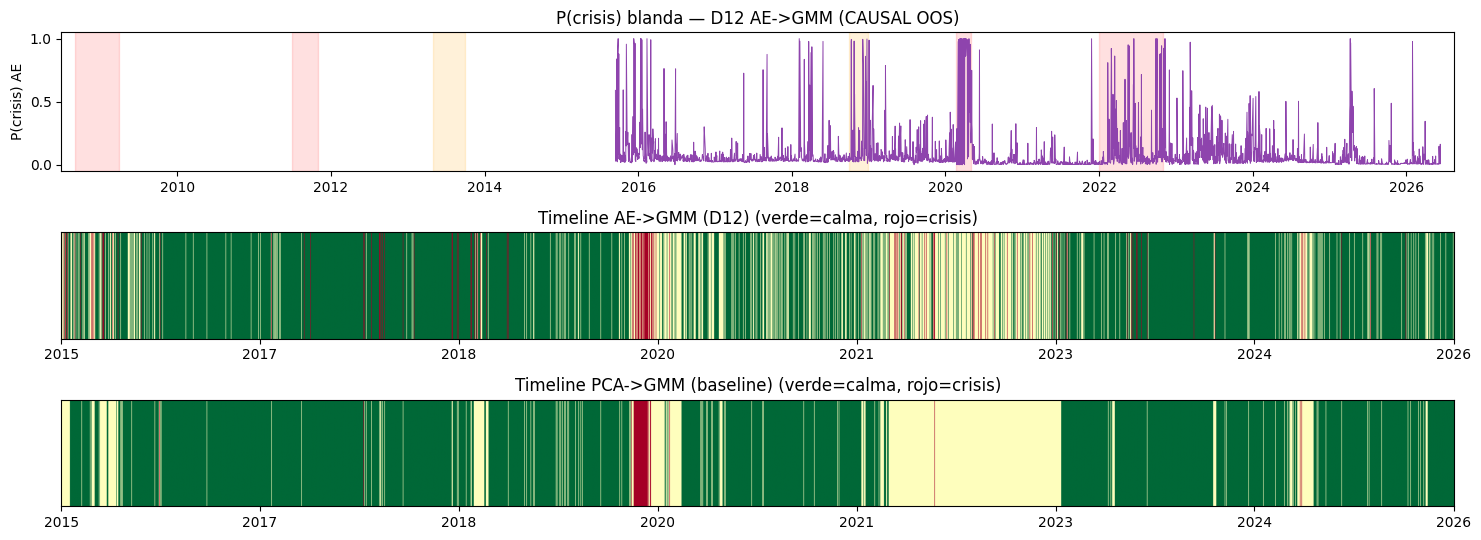

AE : switching=0.2873  dur media=3.5 d
PCA: switching=0.0914  dur media=10.9 d


In [9]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 5.5), gridspec_kw={'height_ratios': [1.3, 1, 1]})
ax1.plot(p_ae.index, p_ae.values, color='#8e44ad', lw=0.7); ax1.set_ylabel('P(crisis) AE')
for a, b in ev.CRISIS_WINDOWS.values(): ax1.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.12)
for a, b in ev.FALSE_POSITIVE_WINDOWS.values(): ax1.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='orange', alpha=0.15)
ax1.set_title('P(crisis) blanda — D12 AE->GMM (CAUSAL OOS)'); ax1.margins(x=0.01)
for ax, st, ttl in [(ax2, states_ae, 'AE->GMM (D12)'), (ax3, states_pca, 'PCA->GMM (baseline)')]:
    ax.imshow(st.values.reshape(1, -1), aspect='auto', cmap='RdYlGn_r', extent=[0, len(st), 0, 1]); ax.set_yticks([])
    tk = np.linspace(0, len(st)-1, 8).astype(int)
    ax.set_xticks(tk); ax.set_xticklabels([st.index[i].year for i in tk])
    ax.set_title(f'Timeline {ttl} (verde=calma, rojo=crisis)')
fig.tight_layout(); fig.savefig(RESULTS / 'd12_timeline.png', dpi=110, bbox_inches='tight'); plt.show()
print(f'AE : switching={res_ae.switching_rate:.4f}  dur media={res_ae.mean_regime_duration:.1f} d')
print(f'PCA: switching={res_pca.switching_rate:.4f}  dur media={res_pca.mean_regime_duration:.1f} d')

## 8. Volcado de métricas a results/ (esquema 23 columnas)

`metrics_12_deep_ae_regime.csv` guarda **dos filas**: D12 (`deep_ae_regime`) y el baseline del
contraste (`pca_gmm_baseline`). El **master** registra solo `deep_ae_regime` (detector del
banco); la PCA es un comparador ablativo, no un detector registrado.

In [10]:
tbl = ev.results_table([res_ae, res_pca])
assert tbl.shape[1] == 23, f'esperaba 23 columnas, hay {tbl.shape[1]}'
tbl.to_csv(RESULTS / 'metrics_12_deep_ae_regime.csv', index=False)
print('Guardado results/metrics_12_deep_ae_regime.csv  (', tbl.shape[0], 'filas,', tbl.shape[1], 'columnas)')

row_ae = ev.results_table([res_ae])  # solo D12 al master
master_path = RESULTS / 'metrics_master.csv'
if master_path.exists():
    master = pd.read_csv(master_path)
    master = master[master['detector'] != 'deep_ae_regime']
    master = pd.concat([master, row_ae], ignore_index=True)
else:
    master = row_ae.copy()
master.to_csv(master_path, index=False)
print('master actualizado:', master.shape)
display(tbl.T)

Guardado results/metrics_12_deep_ae_regime.csv  ( 2 filas, 23 columnas)
master actualizado: (11, 23)


,0,1
detector,deep_ae_regime,pca_gmm_baseline
n_states,3,3
ventana_eval,2015-09-15→2026-06-12 (n=2649),2015-09-15→2026-06-12 (n=2649)
oos_start,2015-09-15,2015-09-15
oos_end,2026-06-12,2026-06-12
n_oos,2649,2649
false_alarm_rate,0.603306,0.135135
switching_rate,0.287278,0.091355
mean_regime_duration,3.476378,10.901235
label_stability,0.964475,0.996977


## 9. Conclusión D12 — ¿aporta la no linealidad del autoencoder?

**Pregunta ablativa:** ¿usar un autoencoder (reductor NO lineal) mejora la detección de
regímenes frente al reductor LINEAL (PCA), con todo lo demás igual (mismo $K$, misma dim
latente, mismo walk-forward causal)?

Lectura (con los números de arriba):
- **Variante principal:** AE→GMM sobre latente 2D; crisis = alta vol de retornos (verificado en
  walk-forward, no invertido, sin fallback). Complemento: el error de reconstrucción del AE como
  score de anomalía (§1b).
- **Orientación y causalidad:** verificadas (encoder puntual con pesos del train; ocultar el
  futuro no altera el latente). OOS ~2015→2026 ⇒ crisis OOS = COVID_2020 + Inflation_2022.
- **Contraste AE vs PCA:** comparar cobertura COVID/Inflation, false_alarm_rate, switching y
  duración media. Con ~4 crisis reales **lo esperado es que el AE NO mejore a la PCA** (incluso
  que flickee más): la no linealidad añade capacidad sin datos suficientes para explotarla. Un
  resultado **NEGATIVO es válido y honesto** — es el aprendizaje de la tanda exploratoria.

(El veredicto numérico definitivo queda en `docs/memory/detectors/12_deep_ae_regime.md`.)